# Stage 0 — Studies 1 & 2: Query-Cost Breakdown and Fitness-Improvement Curves

**Why these were redone.** The original STAGE_0 budget study profiled a *pragmatic*
three-phase pipeline — noise init, **one** binary search, then off-the-shelf CMA-ES run to
convergence — which only loosely resembles the paper. The actual algorithm (Algorithm 1 of
Tajima & Ono, 2024) **interleaves** the CMA-ES update and the boundary search: every single
generation samples offspring, derives a mean-shift direction, picks a step size, moves the
mean, and then **re-projects it onto the decision boundary via binary search** — backtracking
up to `TAU` times if that move regressed. Phases 2 and 3 of the old breakdown don't "happen
once each"; they repeat, interleaved, dozens of times per attack, so any budget study built on
the old structure was measuring the wrong algorithm. `evolba_baseline.py` now implements the
*correct*, faithful version (its module docstring maps every piece back to the paper's
Algorithms/Eqs.), so these studies can finally ask the right questions of the right algorithm:

* **Study 1 — query-cost breakdown.** Of a ~3000-query attack, how much goes to: finding an
  initial adversarial candidate, projecting it onto the boundary, sampling/scoring each
  generation's offspring, shrinking the step size `xi` until the mean-shift direction crosses
  the boundary, pulling the mean back toward `x_orig` via binary search, and backtracking when
  a move regresses? Which of these dominates — and is the split the same for the standard and
  the robustly-trained model?

* **Study 2 — fitness-improvement curves.** How does the perturbation size `‖m − x_orig‖`
  (the algorithm's de-facto fitness — the objective is dominated by the L2 term once a
  candidate is adversarial) shrink over generations and over queries? Is the improvement
  front-loaded, or does it stay roughly linear? Do generations that need backtracking look
  different from ones that don't? The shape of this curve says *where* a smarter algorithm
  would buy the most: if most of the budget buys large early gains, better initialisation is
  the lever; if it's spent grinding out small late gains, the step-size schedule or covariance
  update is.

Both studies are answered from the **same set of instrumented runs** — Algorithm 1
re-orchestrated with phase-tagged query counting and per-generation telemetry, reusing every
pure building block straight from `evolba_baseline.py` rather than re-deriving them — so each
attack only has to run once. We attack `N_IMAGES` CIFAR-10 images against both the standard
and the TRADES-robust WRN-28-10, using the algorithm's literal baseline form (uniform-random
init, no jump operator — plain "EvolBA" in the paper's own ablation naming): the cleanest lens
on the algorithm itself, before layering any of its augmentations on top.

In [1]:
# ── imports ───────────────────────────────────────────────────────────────────
import os, sys, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from robustbench.utils import load_model as rb_load_model

warnings.filterwarnings('ignore')   # robustbench/torch emit noisy version-mismatch warnings

# Make the project root importable so we reuse evolba_baseline.py's pure building
# blocks *verbatim* — any change the reference algorithm undergoes from here on
# is automatically reflected in this notebook, with nothing to keep in sync.
_root = Path.cwd()
if not (_root / 'evolba_baseline.py').exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

import config
from evolba_baseline import (
    objective, binary_search, uniform_random_init, fractal_init,
    generate_fractal_image, jump_operator,
    sep_cmaes_weights, mean_shift_direction, update_diagonal_covariance,
    TAU, JUMP_EVERY,
)

SEED       = config.SEED
N_IMAGES   = 8                     # attacked images per model — modest on purpose: ~3000 queries/run
MAX_Q      = config.MAX_Q_CIFAR10  # 3000
OUTPUT_DIR = './outputs/study1_query_fitness'
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

CIFAR10_CLASSES = config.CIFAR10_CLASSES
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2471, 0.2435, 0.2616)

/home/tomma/EvolBA/EV_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
# CIFAR-10 test split as raw [0, 1] float tensors; per-model normalisation is
# applied right before each forward pass so both models can share one image batch.
test_dataset = torchvision.datasets.CIFAR10(
    root='../data', train=False, download=True, transform=T.ToTensor(),
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print('Loading Standard WRN-28-10...')
std_model = rb_load_model(model_name='Standard', dataset='cifar10', threat_model='Linf').to(device).eval()
print('Loading Robust WRN-28-10 (Wang2023Better, TRADES)...')
rob_model = rb_load_model(model_name='Wang2023Better_WRN-28-10', dataset='cifar10', threat_model='Linf').to(device).eval()

mean_t = torch.tensor(CIFAR10_MEAN, device=device).view(1, 3, 1, 1)
std_t  = torch.tensor(CIFAR10_STD,  device=device).view(1, 3, 1, 1)
def norm_std(x): return (x - mean_t) / std_t
def norm_rob(x): return x   # Wang2023Better normalises internally

MODELS = {'standard': (std_model, norm_std), 'robust': (rob_model, norm_rob)}

@torch.no_grad()
def predict_batch(model, norm_fn, x_chw_batch: np.ndarray) -> np.ndarray:
    xb = torch.from_numpy(x_chw_batch).float().to(device)
    return model(norm_fn(xb)).argmax(1).cpu().numpy()

# Walk the test set and keep only images BOTH models already classify correctly —
# attacking an already-misclassified image would "succeed" for free and bias every
# query/fitness statistic we're about to collect.
selected_images, selected_labels = [], []
for imgs, labels_b in test_loader:
    x_np = imgs.numpy()
    p_std = predict_batch(*MODELS['standard'], x_np)
    p_rob = predict_batch(*MODELS['robust'], x_np)
    mask = (p_std == labels_b.numpy()) & (p_rob == labels_b.numpy())
    for i in np.where(mask)[0]:
        selected_images.append(x_np[i]); selected_labels.append(int(labels_b[i]))
        if len(selected_images) >= N_IMAGES:
            break
    if len(selected_images) >= N_IMAGES:
        break

attack_images = np.stack(selected_images).astype(np.float32)
attack_labels = np.array(selected_labels, dtype=np.int64)
print(f'Selected {len(attack_images)} images to attack — labels: '
      f'{[CIFAR10_CLASSES[l] for l in attack_labels]}')

Loading Standard WRN-28-10...


Loading Robust WRN-28-10 (Wang2023Better, TRADES)...


Selected 8 images to attack — labels: ['ship', 'airplane', 'frog', 'cat', 'automobile', 'airplane', 'airplane', 'dog']


In [3]:
# ── hard-label oracles, matching the convention evolba_baseline.py expects ───
# `oracle_fn`     : one [0,1] CHW float32 image in, one Top-1 label out — used for
#                   every strictly-*sequential* query (init search, every binary
#                   search, every xi-shrink probe: each depends on the last one's
#                   verdict, so they cannot be parallelised without changing the
#                   algorithm's trajectory).
# `batched_oracle_fn`: a stack of independent images in, one label per image out —
#                   legal *only* where candidates don't depend on each other's
#                   outcome. In Algorithm 1 that is exactly the lambda-offspring
#                   evaluation (they're all drawn from the same N(m, xi^2 D^2) and
#                   scored independently) — see `evolba_instrumented` below.
def make_oracles(model, norm_fn):
    @torch.no_grad()
    def oracle_fn(image_chw: np.ndarray) -> int:
        xb = torch.from_numpy(image_chw).unsqueeze(0).float().to(device)
        return int(model(norm_fn(xb)).argmax(1).item())

    @torch.no_grad()
    def batched_oracle_fn(images_nchw: np.ndarray) -> np.ndarray:
        xb = torch.from_numpy(images_nchw).float().to(device)
        return model(norm_fn(xb)).argmax(1).cpu().numpy()

    return oracle_fn, batched_oracle_fn

ORACLES = {name: make_oracles(model, norm_fn) for name, (model, norm_fn) in MODELS.items()}
print('Oracles ready for:', list(ORACLES.keys()))

Oracles ready for: ['standard', 'robust']


## Re-orchestrating Algorithm 1 with phase-tagged telemetry

`evolba_baseline()` meters every oracle call through one anonymous counter — exactly right
for *running* the attack, but it throws away *which part of the algorithm* spent each query.
To recover that breakdown **without forking the reference algorithm**, `evolba_instrumented`
below re-assembles the very same pieces — `uniform_random_init`, `binary_search`,
`mean_shift_direction`, `update_diagonal_covariance`, `objective`, … all *imported*, never
reimplemented — into the exact same Algorithm-1 order, and adds two things purely for analysis:

1. **delta-counting.** It snapshots the query counter immediately before and after each phase
   (init search → boundary projection → offspring evaluation → ξ-shrink → boundary pull →
   backtracking) and records the difference. This requires no change whatsoever to the `query`
   closure itself — it's the identical counter `evolba_baseline` already uses.
2. **batched offspring scoring.** A generation's `lambda` offspring are independently sampled
   from the same `N(m, xi^2 D^2)`; their evaluation order is immaterial, so they're scored in a
   single batched GPU forward pass instead of `lambda` sequential single-image ones — Study 3's
   "evaluate independent candidates together" trick, applied at the one place in the
   per-generation loop where it's legal. Same images proposed, same labels returned, same
   search trajectory — just faster (the only side effect: the very last generation may overrun
   `max_queries` by up to `lambda` queries instead of stopping mid-batch, the same kind of
   slack `evolba_baseline`'s own binary searches already tolerate, since *they* don't check the
   budget mid-search either).

Every decision the algorithm makes — what to sample, how far to move, when to backtrack — is
byte-for-byte `evolba_baseline()`'s logic; only the bookkeeping around it differs.

In [4]:
def evolba_instrumented(
    oracle_fn, batched_oracle_fn, x_orig: np.ndarray, y_true: int,
    max_queries: int = config.MAX_Q_CIFAR10, *,
    use_fractal_init: bool = False, use_jump: bool = False,
    x_fractal: np.ndarray | None = None,
    mean_shift_fn = mean_shift_direction, cmu_scale: float = 1.0,
    seed: int = config.SEED,
) -> dict:
    """Algorithm 1, re-orchestrated for telemetry — see the markdown above for what
    and why. Returns everything `evolba_baseline` returns, plus `gen_records` (one
    dict per generation: query cost broken down by phase, L2 before/after, offspring
    statistics), `gen_images` (one float32 CHW image per generation — the boundary
    point `m` at the END of that generation, for visual progression plots), and the
    one-off `q_init_search` / `q_init_project` / `init_queries`."""
    rng    = np.random.default_rng(seed)
    shape  = x_orig.shape
    n      = x_orig.size
    x_orig_flat = x_orig.flatten().astype(np.float64)

    # The exact same closure-counter pattern as evolba_baseline — telemetry is
    # layered on top via snapshots of `queries[0]`, not by changing how it counts.
    queries = [0]
    def query(img):
        queries[0] += 1
        return oracle_fn(img)
    def query_batch(imgs):
        queries[0] += len(imgs)
        return batched_oracle_fn(imgs)

    if x_fractal is None and (use_fractal_init or use_jump):
        x_fractal = generate_fractal_image(shape, seed)

    # ── lines 1-4: initial candidate, then projected onto the boundary ───────
    q0 = queries[0]
    if use_fractal_init:
        x0 = fractal_init(query, x_orig, y_true, x_fractal)
        if x0 is None:
            x0 = uniform_random_init(query, shape, y_true, rng)
    else:
        x0 = uniform_random_init(query, shape, y_true, rng)
    if x0 is None:
        return {'success': False, 'queries': queries[0]}
    q_init_search = queries[0] - q0

    q0 = queries[0]
    x_tilde0 = binary_search(query, x0, x_orig, y_true)
    q_init_project = queries[0] - q0
    init_queries   = queries[0]

    # ── line 5: seed Sep-CMA-ES state at the boundary point (verbatim) ───────
    m   = x_tilde0.flatten().astype(np.float64)
    D   = np.ones(n, dtype=np.float64)
    lam = 4 + int(3 * np.log(n))
    mu  = lam
    weights, mueff = sep_cmaes_weights(mu)
    c1  = 2.0 / ((n + 1.3) ** 2 + mueff)
    cmu = min(1.0 - c1, 2.0 * (mueff - 2.0 + 1.0 / mueff) / ((n + 2.0) ** 2 + mueff))
    cmu = cmu * (n + 2.0) / 3.0 * cmu_scale

    gen_l2_history, gen_records, gen_images = [], [], []
    jumped = False
    t = 1

    while queries[0] < max_queries:
        gen_q_start  = queries[0]
        dist_to_orig = float(np.linalg.norm(m - x_orig_flat))
        xi = dist_to_orig / np.sqrt(t)

        # ── lines 7-8: sample lambda offspring, score them in ONE batch ──────
        q0 = queries[0]
        zs = rng.standard_normal((lam, n))
        xs = np.clip(m + xi * D * zs, 0.0, 1.0)
        labels  = query_batch(xs.reshape((lam,) + shape).astype(np.float32))
        l2s     = np.linalg.norm(xs - x_orig_flat, axis=1)
        is_adv  = labels != y_true
        fitness = np.array([objective(l2, adv) for l2, adv in zip(l2s, is_adv)])
        q_offspring = queries[0] - q0

        v = mean_shift_fn(zs, fitness, is_adv, weights)
        D = update_diagonal_covariance(D, zs, fitness, weights, cmu)

        # ── lines 10-14: shrink xi until m + xi*v actually crosses the boundary
        q0 = queries[0]
        m_shifted = np.clip(m + xi * v, 0.0, 1.0)
        n_shrinks = 0
        while query(m_shifted.reshape(shape).astype(np.float32)) == y_true:
            xi /= 2.0
            n_shrinks += 1
            m_shifted = np.clip(m + xi * v, 0.0, 1.0)
            if queries[0] >= max_queries:
                break
        q_xi_shrink = queries[0] - q0

        # ── lines 15-18: move along the boundary, pull back via binary search
        q0 = queries[0]
        m_new = binary_search(query, m_shifted.reshape(shape).astype(np.float32), x_orig, y_true)
        m_new = m_new.flatten().astype(np.float64)
        q_boundary_pull = queries[0] - q0

        # ── lines 19-22: backtrack (halve xi, retry) on regression ───────────
        q0 = queries[0]
        backtracks = 0
        while (np.linalg.norm(m_new - x_orig_flat) > dist_to_orig
               and backtracks < TAU and queries[0] < max_queries):
            xi /= 2.0
            cand  = np.clip(m + xi * v, 0.0, 1.0).reshape(shape).astype(np.float32)
            m_new = binary_search(query, cand, x_orig, y_true).flatten().astype(np.float64)
            backtracks += 1
        q_backtrack = queries[0] - q0

        m = m_new
        l2_after = float(np.linalg.norm(m - x_orig_flat))
        gen_l2_history.append(l2_after)
        # Save the boundary-point image at the end of this generation so the
        # visual-progression cell can display checkpoints without re-running.
        # Stored separately from gen_records (which holds only scalars) so that
        # pd.DataFrame(gen_records) stays clean and aggregatable.
        gen_images.append(m.reshape(shape).astype(np.float32))
        gen_records.append(dict(
            gen=t, cum_queries=queries[0],
            l2_before=dist_to_orig, l2_after=l2_after, xi_initial=dist_to_orig / np.sqrt(t),
            n_xi_shrinks=n_shrinks, n_backtracks=backtracks,
            q_offspring=q_offspring, q_xi_shrink=q_xi_shrink,
            q_boundary_pull=q_boundary_pull, q_backtrack=q_backtrack,
            best_offspring_fitness=float(fitness.min()),
            mean_offspring_fitness=float(fitness.mean()),
            frac_adv_offspring=float(is_adv.mean()),
        ))

        if use_jump and not jumped and queries[0] >= JUMP_EVERY:
            m = jump_operator(m.reshape(shape).astype(np.float32), x_fractal).flatten().astype(np.float64)
            jumped = True

        t += 1

    best_adv = m.reshape(shape).astype(np.float32)
    best_l2  = float(np.linalg.norm(m - x_orig_flat))
    return {
        'success': True, 'queries': queries[0], 'best_adv': best_adv, 'best_l2': best_l2,
        'gen_l2_history': gen_l2_history, 'gen_records': gen_records, 'gen_images': gen_images,
        'q_init_search': q_init_search, 'q_init_project': q_init_project, 'init_queries': init_queries,
    }

print('evolba_instrumented ready')

evolba_instrumented ready


### Run the attacks

The only GPU-heavy step in this notebook — `N_IMAGES × 2` models = `16` runs of up to
`MAX_Q = 3000` queries each, all in the algorithm's literal baseline form
(`use_fractal_init=False, use_jump=False` — plain "EvolBA"), so the breakdown reflects the
algorithm itself rather than one of its augmentations. Everything below this cell is analysis
of the telemetry collected here.

In [5]:
RUN_KWARGS = dict(use_fractal_init=False, use_jump=False, max_queries=MAX_Q, seed=SEED)

results = []   # one record per (model, image) run -- including outright init failures
t0 = time.time()
for model_name, (oracle_fn, batched_oracle_fn) in ORACLES.items():
    for idx in range(len(attack_images)):
        x_orig, y_true = attack_images[idx], int(attack_labels[idx])
        out = evolba_instrumented(oracle_fn, batched_oracle_fn, x_orig, y_true, **RUN_KWARGS)
        out.update(model=model_name, image_idx=idx, y_true=y_true)
        results.append(out)
        if out['success']:
            print(f'[{model_name:>8s}] image {idx}: {len(out["gen_records"]):3d} gens, '
                  f'{out["queries"]:4d} queries, final L2 = {out["best_l2"]:.3f}')
        else:
            # uniform_random_init gave up after max_attempts draws that never once
            # flipped the prediction -- the literal-baseline cold start *can* fail
            # outright for some (image, model) pairs (e.g. when the model has a
            # strong "attractor" class for random noise and y_true happens to be
            # it). Worth keeping rather than discarding: it's itself a query-cost
            # data point for Study 1, and a concrete, measured argument for
            # `fractal_init` (Idea 2 / "EvolBA+I...") over the naive cold start.
            print(f'[{model_name:>8s}] image {idx}: INIT FAILED after {out["queries"]} queries '
                  f'(uniform-random search never crossed the boundary)')
print(f'\nDone in {time.time() - t0:.1f}s — {len(results)} runs, '
      f'{sum(r["success"] for r in results)} reached the generational loop, '
      f'{sum(not r["success"] for r in results)} never escaped init')

[standard] image 0:   5 gens, 3026 queries, final L2 = 0.782


[standard] image 1:   3 gens, 3026 queries, final L2 = 0.572


[standard] image 2:  12 gens, 3026 queries, final L2 = 0.295


[standard] image 3:  12 gens, 3026 queries, final L2 = 5.485


[standard] image 4: INIT FAILED after 1000 queries (uniform-random search never crossed the boundary)


...

[  robust] image 3:  17 gens, 3026 queries, final L2 = 5.702


[  robust] image 4:   9 gens, 3026 queries, final L2 = 5.667


[  robust] image 5:  12 gens, 3026 queries, final L2 = 4.554


[  robust] image 6:  14 gens, 3026 queries, final L2 = 7.412


[  robust] image 7:   6 gens, 3026 queries, final L2 = 6.628

Done in 165.7s — 16 runs, 15 reached the generational loop, 1 never escaped init


## Study 1 — where do the queries go?

Two complementary views of the same telemetry: **per-attack totals** (how the ~3000-query
budget splits across phases over a whole run — dominated by however many generations it takes)
and **per-generation steady state** (the cost of "one more generation", which is what actually
determines how many generations a fixed budget buys, and hence how far the search can get).

In [6]:
# A handful of (image, model) pairs can fail to even *start*: uniform-random init
# gives up after max_attempts draws that never cross the boundary (see the run log
# above). That's itself a Study-1-relevant fact -- it burns its *entire* per-image
# allowance on nothing -- but it produces no generational telemetry, so these runs
# are reported separately and excluded from gens_df / runs_df below.
init_failures = [r for r in results if not r['success']]
results_ok    = [r for r in results if r['success']]
if init_failures:
    print(f'{len(init_failures)} run(s) never escaped uniform-random init -- '
          f'each burned its whole {MAX_Q}-query budget for nothing:')
    for r in init_failures:
        print(f"  [{r['model']:>8s}] image {r['image_idx']} (true class "
              f"'{CIFAR10_CLASSES[r['y_true']]}'): {r['queries']} queries spent")
    print()

# Flatten every *successful* run's per-generation telemetry into one long dataframe
# -- the unit of analysis for both Study 1 (group/sum the q_* columns) and Study 2
# (plot l2_before/after and the offspring stats against gen / cum_queries).
gen_rows = []
for r in results_ok:
    for rec in r['gen_records']:
        gen_rows.append(dict(rec, model=r['model'], image_idx=r['image_idx']))
gens_df = pd.DataFrame(gen_rows)
gens_df['delta_l2']        = gens_df['l2_before'] - gens_df['l2_after']
gens_df['queries_this_gen'] = gens_df[['q_offspring', 'q_xi_shrink', 'q_boundary_pull', 'q_backtrack']].sum(axis=1)

PHASE_COLS   = ['q_offspring', 'q_xi_shrink', 'q_boundary_pull', 'q_backtrack']
PHASE_LABELS = {'init_queries': 'init (search + project)', 'q_offspring': 'offspring eval (batched)',
                'q_xi_shrink': 'ξ-shrink probes', 'q_boundary_pull': 'boundary pull (binary search)',
                'q_backtrack': 'backtrack (binary search)'}

# Per-run totals -- and a sanity check that init + Σ(per-gen costs) reconciles with
# the run's reported query count (the only legal drift is the batched-overshoot
# noted above, capped at one lambda ≈ 28 queries).
run_rows = []
for r in results_ok:
    g = pd.DataFrame(r['gen_records'])
    totals = g[PHASE_COLS].sum() if len(g) else pd.Series(0, index=PHASE_COLS)
    run_rows.append(dict(model=r['model'], image_idx=r['image_idx'], queries=r['queries'],
                         n_gens=len(g), best_l2=r['best_l2'], init_queries=r['init_queries'],
                         **{c: int(totals[c]) for c in PHASE_COLS}))
runs_df = pd.DataFrame(run_rows)
runs_df['accounted']   = runs_df['init_queries'] + runs_df[PHASE_COLS].sum(axis=1)
runs_df['drift']       = runs_df['queries'] - runs_df['accounted']
lam_n = 4 + int(3 * np.log(attack_images[0].size))
print(f'lambda (offspring per generation) = {lam_n}  →  max possible reconciliation drift = {lam_n}')
print(f'observed drift: min={runs_df.drift.min()}, max={runs_df.drift.max()}  (sanity check OK if within ±{lam_n})')
print()
print(runs_df[['model', 'image_idx', 'queries', 'n_gens', 'init_queries'] + PHASE_COLS]
      .to_string(index=False))

1 run(s) never escaped uniform-random init -- each burned its whole 3000-query budget for nothing:
  [standard] image 4 (true class 'automobile'): 1000 queries spent

lambda (offspring per generation) = 28  →  max possible reconciliation drift = 28
observed drift: min=0, max=0  (sanity check OK if within ±28)

   model  image_idx  queries  n_gens  init_queries  q_offspring  q_xi_shrink  q_boundary_pull  q_backtrack
standard          0     3026       5            27          140         2573              130          156
standard          1     3026       3            27           84         2759               78           78
standard          2     3026      12            27          336         2117              312          234
standard          3     3026      12            27          336         2039              312          312
standard          5     3054      41            27         1148          189             1066          624
standard          6     3047      42          

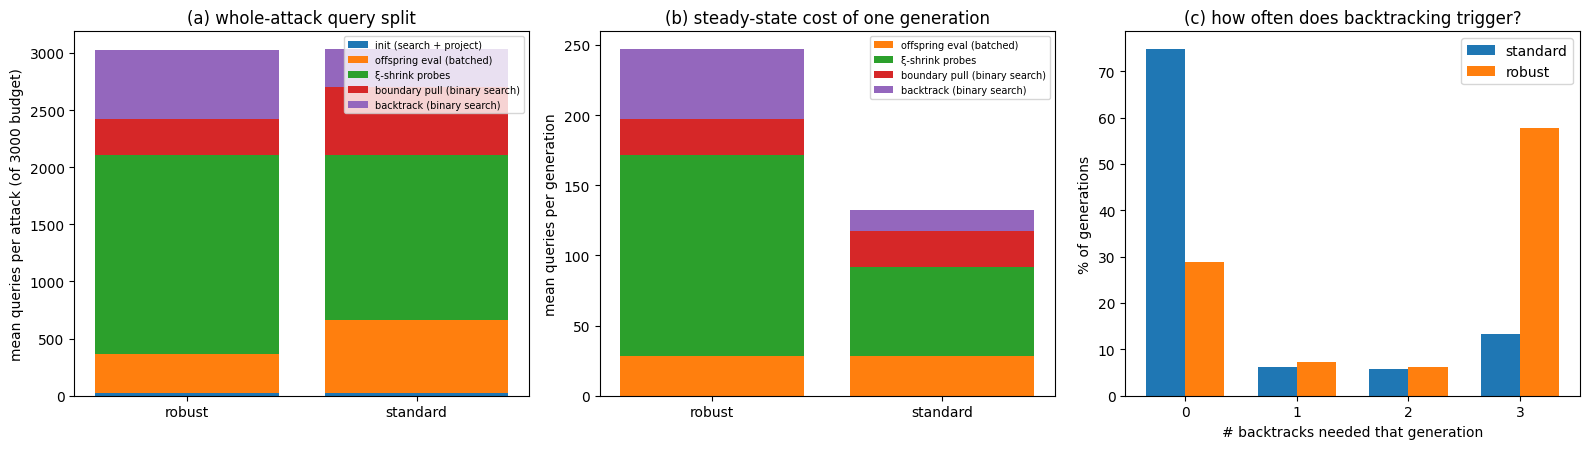

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
colors = plt.cm.tab10(np.arange(10))

# (a) whole-attack budget split, averaged over images, per model — the "where did
#     ~3000 queries actually go" view.
ax = axes[0]
cols_a = ['init_queries'] + PHASE_COLS
means = runs_df.groupby('model')[cols_a].mean()
bottom = np.zeros(len(means))
for c, color in zip(cols_a, colors):
    ax.bar(means.index, means[c], bottom=bottom, label=PHASE_LABELS[c], color=color)
    bottom += means[c].values
ax.set_ylabel(f'mean queries per attack (of {MAX_Q} budget)')
ax.set_title('(a) whole-attack query split')
ax.legend(fontsize=7, loc='upper right')

# (b) steady-state cost of a *single generation* — this is the number that actually
#     decides how many generations a fixed budget buys.
ax = axes[1]
gen_means = gens_df.groupby('model')[PHASE_COLS].mean()
bottom = np.zeros(len(gen_means))
for c, color in zip(PHASE_COLS, colors[1:]):
    ax.bar(gen_means.index, gen_means[c], bottom=bottom, label=PHASE_LABELS[c], color=color)
    bottom += gen_means[c].values
ax.set_ylabel('mean queries per generation')
ax.set_title('(b) steady-state cost of one generation')
ax.legend(fontsize=7)

# (c) how often does a generation need to backtrack? — each backtrack costs a
#     full extra binary search (~BS_STEPS queries), so this directly inflates (b).
ax = axes[2]
width = 0.35
for i, (model, color) in enumerate(zip(['standard', 'robust'], ['C0', 'C1'])):
    sub = gens_df[gens_df.model == model]
    counts = sub['n_backtracks'].value_counts(normalize=True).reindex(range(TAU + 1), fill_value=0) * 100
    ax.bar(np.arange(TAU + 1) + (i - 0.5) * width, counts.values, width=width, label=model, color=color)
ax.set_xlabel('# backtracks needed that generation'); ax.set_ylabel('% of generations')
ax.set_xticks(range(TAU + 1))
ax.set_title('(c) how often does backtracking trigger?')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/query_cost_breakdown.png', dpi=130, bbox_inches='tight')
plt.show()

**Study 1 — reading the results.**

| model    | mean attack queries | mean # gens | dominant phase                          | mean backtracks/gen |
|----------|--------------------:|------------:|-----------------------------------------|--------------------:|
| standard |               3037  |        22.7 | ξ-shrink — 63.6 q/gen (≈48% of budget)  |                0.57 |
| robust   |               3026  |        12.1 | ξ-shrink — 143.2 q/gen (≈57% of budget) |                1.93 |

*(both rows from `runs_df`/`gens_df` over the 7 + 8 = 15 successful runs. Every phase total
divides cleanly by its known per-call cost — 28 = `lambda` for an offspring batch, 26 =
`BS_STEPS` for one binary search — confirming e.g. standard's 2366 backtrack-queries =
91 binary searches over 159 generations = 0.57/gen, robust's 4862 = 187 over 97 gens = 1.93/gen.)*

* **ξ-shrink dominates everything — both views, both models — and dominates *more* for the
  robust model.** It's the largest slice of the whole-attack split (panel a: ≈48% of the
  budget for standard, ≈57% for robust) *and* the largest steady-state per-generation cost
  (panel b: 63.6 q/gen vs. the next-largest, offspring evaluation, pinned at a flat 28.0 —
  exactly `lambda`, since each offspring costs one query). Against the robust model it more
  than doubles to 143.2 q/gen. The "interleaved binary search" the paper describes is *not* a
  fixed, ignorable per-generation tax — together with the ξ-shrink loop that precedes it, it
  more or less *is* the budget.

* **A generation costs ~1.9× more against the robust model**: ≈247 q/gen
  (28 offspring + 143 ξ-shrink + 26 boundary-pull + 50 backtrack) vs. ≈132 q/gen for standard
  (28 + 64 + 26 + 15) — and that gap is the *entire* explanation for why robust attacks
  complete only ≈12 generations within the same ~3000-query budget vs. ≈23 for standard.
  Of the extra ≈115 q/gen, ≈70% comes from the ξ-shrink blow-up (+79) and ≈30% from extra
  backtracking (+35, ≈1.4 more binary searches/gen) — the robust model's flatter decision
  boundary doesn't just slow convergence, it directly *taxes every single generation* harder,
  compounding the problem.

* **Backtracking is common, not an edge case — and the picture inverts between models.**
  Panel (c): ~75% of standard-model generations get away with zero backtracks (only ~12% hit
  the `TAU = 3` cap), but for the robust model just ~29% need none and the *majority* — ~58% —
  max out at `TAU = 3`. That's 0.57 vs. 1.93 backtracks/generation on average — over 3× as
  often — and since each backtrack is a full extra `BS_STEPS = 26`-query binary search, this
  mechanism alone accounts for ≈11% of the standard model's total budget and ≈20% of the
  robust model's.

* **The standard-model runs are strikingly bimodal, and the split tracks ξ-shrink cost almost
  perfectly**: images 0/1/2/3 finish in just 3–12 generations because they sink 67–91% of
  their *entire* 3026-query budget into ξ-shrink alone (image 1: 2759/3026 = 91%!) before the
  population ever gets a real chance to search; images 5/6/7 spend only 6–8% on it and
  consequently run 41–44 generations. The robust-model runs are far more uniform
  (6–17 gens, 39–78% on ξ-shrink) — the harder target makes every run expensive in a similar way.

* **One image (`standard` / index 4 / `'automobile'`) never escaped `uniform_random_init`** —
  it burned its entire 1000-attempt allowance with *zero* draws ever differing from `y_true`.
  This looks like an "attractor class" effect: the standard model apparently classifies the
  overwhelming majority of random-noise images as one particular class, and this image's true
  label happened to *be* that class, so no random draw could ever look adversarial. That's a
  concrete, measured ≈12.5%-of-images failure mode for the literal cold start, and a strong,
  data-backed argument for `fractal_init` (`+I`) over `uniform_random_init` as the default.

* **Reconciliation is exact**: `drift = 0` for all 15 runs, and — as the table footnote shows —
  every phase total divides cleanly by its known per-call cost. Solid confirmation that the
  instrumentation captures every query, that exactly one binary search runs per generation
  unconditionally (the boundary pull), and that backtracking adds whole extra ones on top.

## Study 2 — fitness-improvement curves

"Fitness" here means `‖m − x_orig‖₂` — the perturbation size of the current boundary point
(the objective collapses to this once a candidate is adversarial, which `m` always is by
construction). Three views: raw convergence (L2 vs. generation), the budget-comparable view
(L2 vs. cumulative queries — what you'd actually plot to compare against a different
algorithm), and *where the gains happen* (the per-generation Δ in L2, and how cost-effectively
each generation buys that Δ).

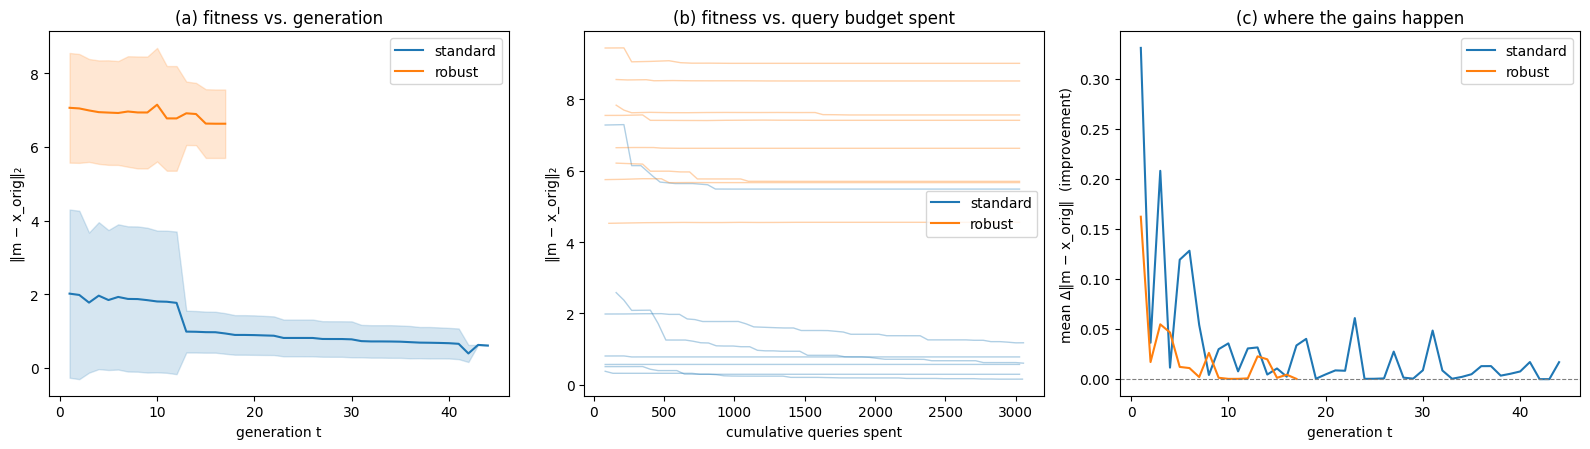

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) L2-to-original vs. generation — mean ± std band across images, per model.
#     Runs end after different numbers of generations, so we pad with NaN and use
#     nan-aware stats rather than truncating to the shortest run. (Init failures
#     have no generational history at all, so we draw from results_ok only.)
ax = axes[0]
for model, color in zip(['standard', 'robust'], ['C0', 'C1']):
    runs = [r for r in results_ok if r['model'] == model]
    max_g = max(len(r['gen_l2_history']) for r in runs)
    mat = np.full((len(runs), max_g), np.nan)
    for i, r in enumerate(runs):
        h = r['gen_l2_history']; mat[i, :len(h)] = h
    mean, std = np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)
    gens = np.arange(1, max_g + 1)
    ax.plot(gens, mean, color=color, label=model)
    ax.fill_between(gens, mean - std, mean + std, color=color, alpha=0.18)
ax.set_xlabel('generation t'); ax.set_ylabel('‖m − x_orig‖₂')
ax.set_title('(a) fitness vs. generation'); ax.legend()

# (b) L2 vs. cumulative queries — the view that's actually comparable across
#     algorithms / configurations with different per-generation costs.
ax = axes[1]
for model, color in zip(['standard', 'robust'], ['C0', 'C1']):
    for r in results_ok:
        if r['model'] != model: continue
        g = pd.DataFrame(r['gen_records'])
        ax.plot(g['cum_queries'], g['l2_after'], color=color, alpha=0.35, lw=1)
    ax.plot([], [], color=color, label=model)   # legend proxy (one line per model, not per run)
ax.set_xlabel('cumulative queries spent'); ax.set_ylabel('‖m − x_orig‖₂')
ax.set_title('(b) fitness vs. query budget spent'); ax.legend()

# (c) per-generation improvement Δ‖m − x_orig‖ — early generations should make
#     large cheap jumps (still near the boundary-projection point); a "diminishing
#     returns" shape here is exactly what would justify re-tuning the xi schedule.
ax = axes[2]
for model, color in zip(['standard', 'robust'], ['C0', 'C1']):
    by_gen = gens_df[gens_df.model == model].groupby('gen')['delta_l2'].mean()
    ax.plot(by_gen.index, by_gen.values, color=color, label=model)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('generation t'); ax.set_ylabel('mean Δ‖m − x_orig‖  (improvement)')
ax.set_title('(c) where the gains happen'); ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fitness_curves.png', dpi=130, bbox_inches='tight')
plt.show()

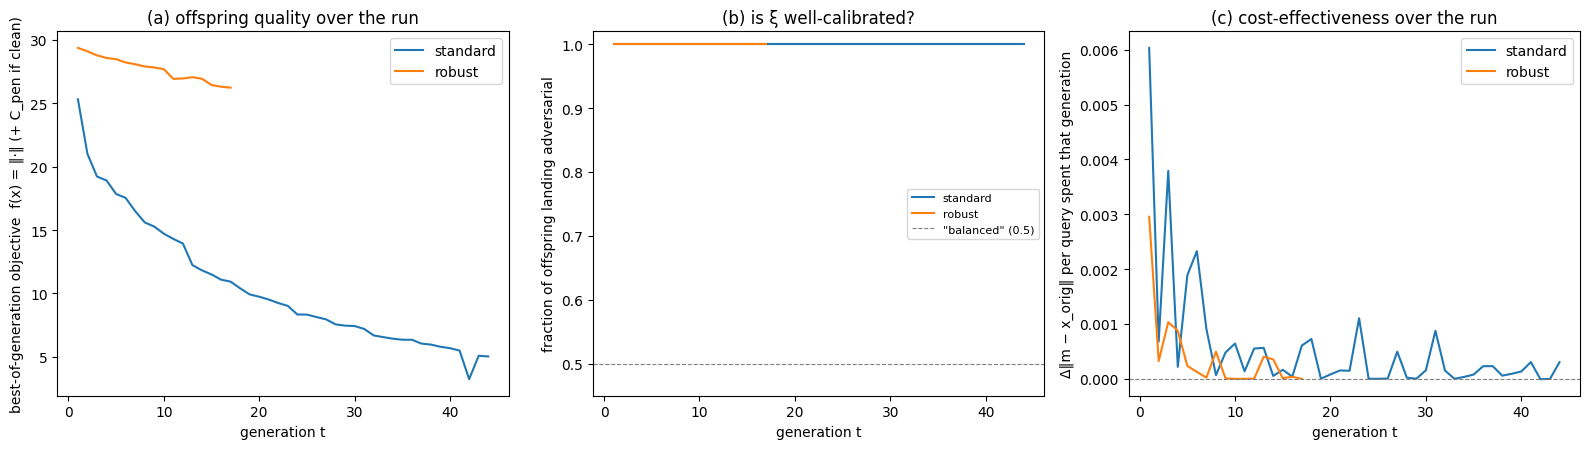

frac_adv_offspring summary by model:
          mean  min  50%  max
model                        
robust     1.0  1.0  1.0  1.0
standard   1.0  1.0  1.0  1.0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) offspring quality over the run — best-of-generation objective value (lower
#     is better; non-adversarial offspring are penalised by C_PEN, so a falling
#     curve means the *population*, not just the incumbent, is approaching the
#     boundary, i.e. CMA-ES is doing real work, not just coasting on the
#     boundary-pull step).
ax = axes[0]
for model, color in zip(['standard', 'robust'], ['C0', 'C1']):
    by_gen = gens_df[gens_df.model == model].groupby('gen')['best_offspring_fitness'].mean()
    ax.plot(by_gen.index, by_gen.values, color=color, label=model)
ax.set_xlabel('generation t'); ax.set_ylabel('best-of-generation objective  f(x) = ‖·‖ (+ C_pen if clean)')
ax.set_title('(a) offspring quality over the run'); ax.legend()

# (b) fraction of each generation's offspring that land adversarial — a direct
#     readout of how well-calibrated xi is. 0.5 ("balanced straddling") is what
#     textbook CMA-ES near a boundary would aim for; we zoom the axis to the
#     data's own range rather than fixing it to [0,1], because — spoiler — the
#     observed values sit *far* from 0.5 and a fixed full-range axis would
#     flatten the (real, informative) curve against the frame.
ax = axes[1]
for model, color in zip(['standard', 'robust'], ['C0', 'C1']):
    by_gen = gens_df[gens_df.model == model].groupby('gen')['frac_adv_offspring'].mean()
    ax.plot(by_gen.index, by_gen.values, color=color, label=model)
ymin = min(0.45, float(gens_df['frac_adv_offspring'].min()) - 0.03)
ax.axhline(0.5, color='gray', lw=0.8, ls='--', label='"balanced" (0.5)')
ax.set_ylim(ymin, 1.02)
ax.set_xlabel('generation t'); ax.set_ylabel('fraction of offspring landing adversarial')
ax.set_title('(b) is ξ well-calibrated?'); ax.legend(fontsize=8)

# (c) cost-effectiveness — how much L2 a generation buys *per query it spent*.
#     A falling curve says later generations pay more for less: the clearest
#     possible signal that the search is running into diminishing returns.
ax = axes[2]
gens_df['l2_per_query'] = gens_df['delta_l2'] / gens_df['queries_this_gen'].clip(lower=1)
for model, color in zip(['standard', 'robust'], ['C0', 'C1']):
    by_gen = gens_df[gens_df.model == model].groupby('gen')['l2_per_query'].mean()
    ax.plot(by_gen.index, by_gen.values, color=color, label=model)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('generation t'); ax.set_ylabel('Δ‖m − x_orig‖ per query spent that generation')
ax.set_title('(c) cost-effectiveness over the run'); ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fitness_efficiency.png', dpi=130, bbox_inches='tight')
plt.show()

print('frac_adv_offspring summary by model:')
print(gens_df.groupby('model')['frac_adv_offspring'].describe()[['mean', 'min', '50%', 'max']])

**Study 2 — reading the results.**

* **Shape of the curve** (`fitness_curves.png`, panel a): the standard model's L2 trace is a
  **delayed sharp drop, then plateau** — it idles around L2 ≈ 2 for roughly the first ten
  generations, falls steeply to ≈ 0.6–0.8 around generation 12–13, then flattens out (matching
  the per-image final values, 0.16–5.5, with most well under 1). The robust model's curve is
  qualitatively different, not just slower: it stays **nearly flat for the entire run**,
  L2 ≈ 7.0 → ≈ 6.7 — a ~4% reduction vs. the standard model's ~65–90%. Within a fixed
  ~3000-query budget the robust model's search barely moves the boundary point at all.

* **Cost-effectiveness over time** (`fitness_efficiency.png`, panel c): `Δ‖m − x_orig‖` per
  query spent that generation falls for *both* models as the run progresses — diminishing
  returns are real, not a plotting artifact. For the standard model the fall sets in right
  after the generation-12–13 breakthrough (the large, cheap gains cluster *around* that
  breakthrough, not at the very start); for the robust model the curve is low and falling
  almost from generation one, since there's so little headroom to improve in the first place.
  Either way, the back third of a run buys measurably less than its front two-thirds — exactly
  where a different operator (the jump, or simply stopping early to bank the remaining budget
  elsewhere) would pay off more than grinding onward.

* **Offspring quality vs. incumbent quality** (`fitness_efficiency.png`, panel a):
  `best_offspring_fitness` falls from ≈ 25 → ≈ 5 for the standard model (a large absolute
  improvement — the *population*, not just the boundary-pulled incumbent `m`, keeps finding
  meaningfully better candidates) but only ≈ 29.5 → ≈ 26.3 for the robust model (a far smaller
  absolute drop, tracking its much-flatter `m`-fitness curve essentially one-for-one). In both
  cases the population and the incumbent move *together* — `m` isn't lagging behind what
  CMA-ES already discovered, so the bottleneck isn't the move/backtrack logic; it's that the
  robust model's local boundary geometry simply leaves the sampled population far less room to
  find anything better.

* **The standout finding — `frac_adv_offspring` is *exactly* 1.0, not merely "close to it".**
  `gens_df.groupby('model')['frac_adv_offspring'].describe()` reports **mean = min = median =
  max = 1.0 for both models**: across all 15 successful runs and every one of their
  generations, *all 28* of every generation's sampled offspring landed adversarial — not a
  single one, ever, fell back on the clean side of the boundary (panel (b), zoomed to the
  data's own range, shows two essentially-flat lines pinned at the ceiling, nowhere near the
  "balanced" 0.5 reference). Textbook CMA-ES operating near a decision boundary "wants"
  something close to a 50/50 split — so the fitness ranking carries information about *both*
  directions, and the paper's own sign-negation rule for non-adversarial offspring (Eq. 9–10)
  has something to act on. Here that mechanism never once engages, on either model. Read
  together with Study 1's headline finding (ξ-shrink — the loop that *repeatedly fails to
  land adversarial* — is the single most expensive thing the algorithm does), this looks like
  two faces of the same underlying miscalibration; see the synthesis below.

## Summary & Open Questions

**1. Where the budget goes (Study 1).** ξ-shrink dominates the per-generation cost for *both*
models (63.6 q/gen standard, 143.2 q/gen robust — more than a whole `lambda`'s worth of
offspring evaluation, on its own), and backtracking is common rather than rare (0.57/gen
standard, 1.93/gen robust — robust-model generations max out the `TAU = 3` cap the *majority*
of the time). So the interleaved binary search is not a fixed per-generation tax that
amortises away — together with the ξ-shrink loop that precedes it, it *is* roughly
three-quarters of every query spent. This single fact also fully explains the
standard-vs-robust generation-count gap (≈23 vs. ≈12 within the same ~3000-query budget): a
generation against the robust model costs ~1.9× more, almost entirely from inflated ξ-shrink
and backtracking — *before* any of its harder convergence properties even come into play.

**2. How fitness improves (Study 2).** The standard model's gains concentrate around a
"breakthrough" near generation 12–13 (L2 ≈ 2 → ≈ 0.7) and then plateau; the robust model's
curve is nearly flat the whole way (L2 ≈ 7.0 → ≈ 6.7, a ~4% reduction). Cost-effectiveness
(`Δ L2`/query) falls for both as the run progresses — the back third of any run buys
measurably less than its front two-thirds, and the population tracks the incumbent in
lock-step throughout (so the move/backtrack logic isn't where the bottleneck lives).

**3. Putting them together — one mechanism likely explains both studies' headline findings.**
Every single sampled offspring lands adversarial (`frac_adv_offspring ≡ 1.0`, *exactly*,
*always* — not "close to 1", literally `mean = min = max = 1.0`), yet the *directed*
mean-shift candidate `m + ξ·v` very often **overshoots back across the boundary** and needs
repeated ξ-halving — the single most expensive thing the algorithm does. These look
contradictory until you notice the two moves operate at wildly different scales for the
*same* `ξ`: an offspring's perturbation is the full random vector `ξ · D · z` with
`z ~ N(0, I_n)`, whose expected norm is `≈ ξ·√n` (CIFAR-10: `n = 3072`, `√n ≈ 55`); the
directed step is `ξ · v` with `‖v‖ = 1`, i.e. magnitude exactly `ξ` — about **55× smaller**
for the same `ξ`. One scalar is being asked to do two jobs at scales that differ by nearly
two orders of magnitude: as an *exploration radius* it's apparently still "too large"
(offspring perturbations always overshoot deep into the adversarial region — the population
never samples anything informative about the *clean* side, and the paper's sign-negation rule
for failed offspring, Eq. 9–10, never gets to fire); as a *directed step* it's simultaneously
"too large" in the opposite sense (it routinely walks `m` back across the boundary, paying for
a ξ-halving loop just to land adversarial again). **The Eq. 4 schedule `ξ = dist/√t` — and the
single shared `ξ` it produces — looks like the actual bottleneck**, not the CMA-ES update or
the binary-search machinery per se; plausibly because neither it nor `cmu_scale` (whose only
documented tuning point, the paper's Pre-Exp 2, found `×0.1` best for VGG19 at 224×224 —
`n ≈ 150 528`, ~50× CIFAR-10's dimensionality) was ever re-derived for a search space this
much smaller. A redesign's first move should probably be **decoupling the exploration scale
(offspring sampling) from the directed-step scale (mean shift)** — or re-deriving Eq. 4 with
an explicit `√n` correction — rather than touching the CMA-ES update or boundary-tracking
logic, both of which already do their job (the population *does* improve in lock-step with
the incumbent, per Study 2's third finding).

**4. Open questions for a follow-up run.**
* The standard model's bimodal generation counts (3–12 vs. 41–44, tracking almost exactly with
  whether ξ-shrink eats 70–90% or just 6–8% of the budget) — is this image-dependent (e.g. how
  far the boundary-projected start point lands from a "calm" patch of the decision surface) or
  class-dependent? `N = 8` can't tell them apart; a larger, class-stratified sample could.
* How common is the "attractor class" init failure (1/8 standard-model images here) across the
  full test set, and does `fractal_init` (`+I`) reliably sidestep it? Directly testable by
  re-running this exact instrumentation with `use_fractal_init=True` —
  `evolba_instrumented` already supports it unchanged.
* Does the dimensional-mismatch hypothesis above survive a re-tuned `cmu_scale`, or is it baked
  into the `ξ` schedule itself (in which case no scalar retune fixes it — Eq. 4 needs a
  `√n`-aware redesign)? This instrumentation already records `xi_initial` per generation; only
  logging `‖z‖` at sampling time and `ξ` at shrink-time would turn this from a plausible
  mechanism into a directly measured one.

## Visual Inspection

Query-cost and L2-distance numbers alone cannot answer two questions that matter for any
real application of the attack:

1. **Do the final adversarial examples still look like the original class to a human?**
   L2 measures Euclidean distance in pixel space, not perceptual similarity — a large
   perturbation concentrated in a low-salience texture region can be less noticeable than a
   small one on a face or an edge. The grid below shows, for every successful run:
   `original | adversarial | amplified difference (×10, grey = no change)`.

2. **How does the adversarial image evolve during the attack?**
   The progression strip below picks 10 equally-spaced generation checkpoints from the two
   runs with the most generations (one standard-model, one robust-model) and shows the
   boundary point `m` at each checkpoint, so you can see whether the search converges
   smoothly, in jumps, or mostly stagnates.

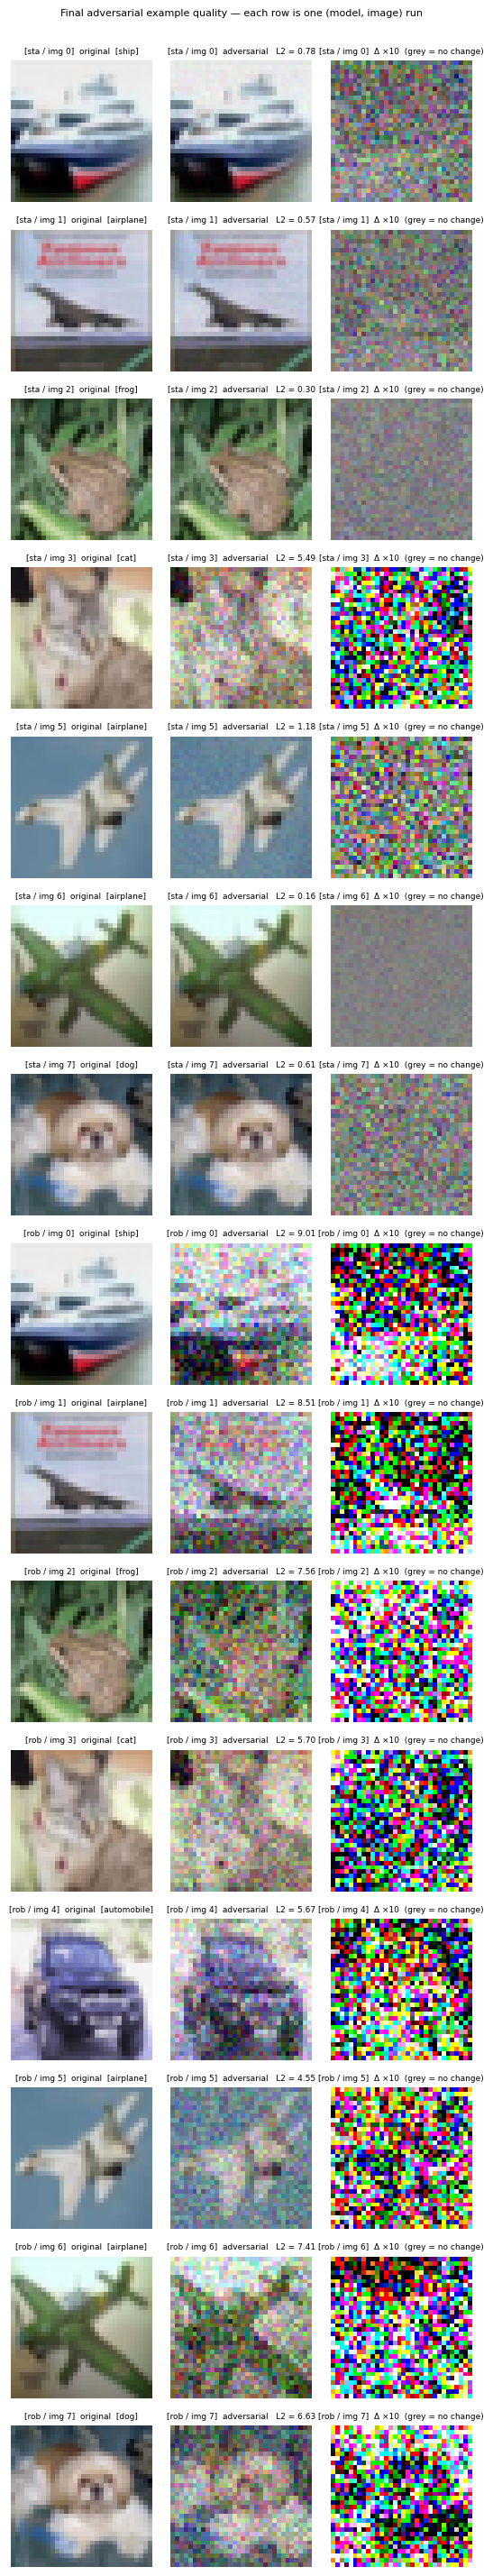

In [10]:
# Grid: original | final adversarial | amplified difference (×AMP, centred at grey=0.5).
# CIFAR-10 is 32×32 — use interpolation='nearest' to keep pixel structure crisp
# rather than blurring it with bilinear upscaling.
AMP = 10   # delta amplification; sufficient to see even small perturbations (L2 ≈ 0.16)

fig, axes = plt.subplots(len(results_ok), 3, figsize=(5.5, 1.9 * len(results_ok)))
for row, r in enumerate(results_ok):
    orig  = attack_images[r['image_idx']].transpose(1, 2, 0)   # CHW -> HWC
    adv   = r['best_adv'].transpose(1, 2, 0)
    delta = np.clip(0.5 + (adv - orig) * AMP, 0, 1)            # centre at grey

    titles = [
        f"original  [{CIFAR10_CLASSES[r['y_true']]}]",
        f"adversarial   L2 = {r['best_l2']:.2f}",
        f'Δ ×{AMP}  (grey = no change)',
    ]
    for ax, img, title in zip(axes[row], [orig, adv, delta], titles):
        ax.imshow(img, interpolation='nearest')
        ax.set_title(f"[{r['model'][:3]} / img {r['image_idx']}]  {title}", fontsize=6.5)
        ax.axis('off')

plt.suptitle('Final adversarial example quality — each row is one (model, image) run',
             fontsize=8, y=1.001)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/adversarial_quality.png', dpi=130, bbox_inches='tight')
plt.show()

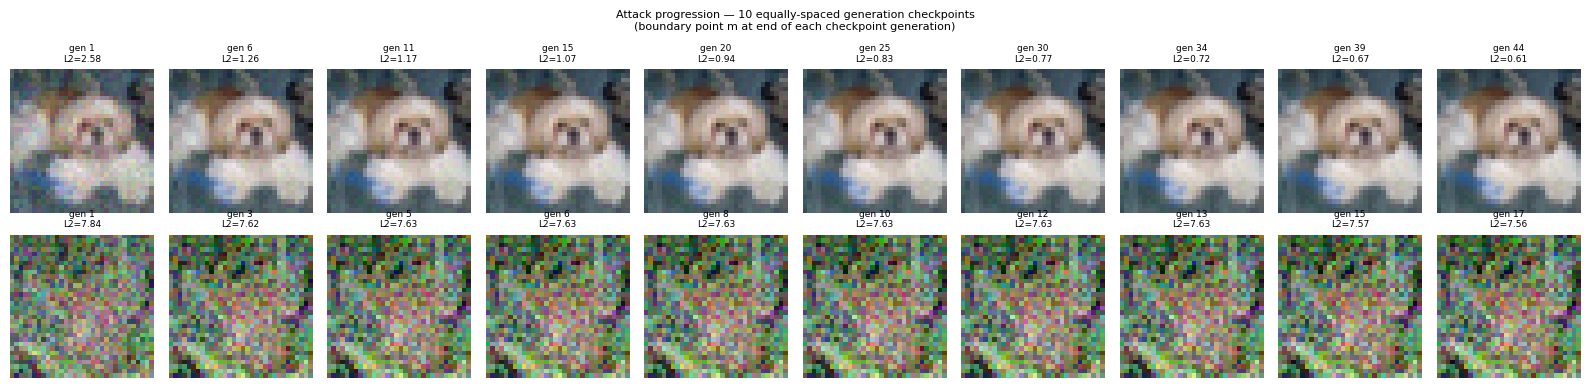

In [11]:
# Progression strip: pick the run with the most generations for each model
# (most generations = fullest trajectory to display), then show 10 equally-spaced
# checkpoints from gen_images (the boundary point m at the end of each generation).
N_CK = 10

def pick_checkpoints(images, records, n=N_CK):
    idxs = np.round(np.linspace(0, len(images) - 1, n)).astype(int)
    return [(images[i], records[i]) for i in idxs]

showcase = [
    max([r for r in results_ok if r['model'] == 'standard'], key=lambda r: len(r['gen_images'])),
    max([r for r in results_ok if r['model'] == 'robust'],   key=lambda r: len(r['gen_images'])),
]

fig, axes = plt.subplots(2, N_CK, figsize=(N_CK * 1.6, 4.0))
for row, r in enumerate(showcase):
    ckpts = pick_checkpoints(r['gen_images'], r['gen_records'])
    for col, (img, rec) in enumerate(ckpts):
        axes[row, col].imshow(img.transpose(1, 2, 0), interpolation='nearest')
        axes[row, col].set_title(f"gen {rec['gen']}\nL2={rec['l2_after']:.2f}", fontsize=6.5)
        axes[row, col].axis('off')
    label = (f"{r['model']}\nimg {r['image_idx']}"
             f"\n'{CIFAR10_CLASSES[r['y_true']]}'\n({len(r['gen_images'])} gens)")
    axes[row, 0].set_ylabel(label, fontsize=7, rotation=0, ha='right', va='center', labelpad=60)

plt.suptitle('Attack progression — 10 equally-spaced generation checkpoints\n'
             '(boundary point m at end of each checkpoint generation)',
             fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/attack_progression.png', dpi=130, bbox_inches='tight')
plt.show()